In [40]:
from dotenv import load_dotenv
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from langchain_mistralai import ChatMistralAI

load_dotenv()

True

# Basic Workflow

In [31]:
class BMI_State(TypedDict):
    
    weight_kg: float
    height_m: float
    bmi: float
    category: str

In [36]:
def calculate_BMI(state: BMI_State) -> BMI_State:
    
    weight= state['weight_kg']
    height= state['height_m']
    
    bmi= weight/(height**2)
    state['bmi']= round(bmi, 2)
    
    return state

def label_BMI(state: BMI_State) -> BMI_State:
    
    if state['bmi'] < 18.5:
        state['bmi_label']= 'Underweight'
    elif state['bmi'] < 25:
        state['bmi_label']= 'Normal'
    else:
        state['bmi_label']= 'Overweight'
    
    state['category']= state['bmi_label']
        
    return state

In [37]:
graph= StateGraph(BMI_State)

graph.add_node('calculate_BMI', calculate_BMI)
graph.add_node('label_BMI', label_BMI)

graph.add_edge(START, 'calculate_BMI')
graph.add_edge('calculate_BMI', 'label_BMI')
graph.add_edge('label_BMI', END)

workflow= graph.compile()

In [38]:
initial_state= {
    'weight_kg': 70,
    'height_m': 1.82
}

final_state= workflow.invoke(initial_state)

print(final_state)

{'weight_kg': 70, 'height_m': 1.82, 'bmi': 21.13, 'category': 'Normal'}


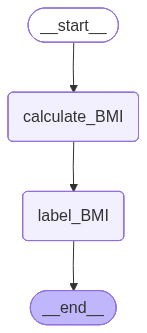

In [39]:
from IPython.display import Image

Image(workflow.get_graph().draw_mermaid_png())

# Simple LLM Workflow

In [45]:
model= ChatMistralAI(model_name='mistral-small-latest')

In [46]:
class LLM_State(TypedDict):
    
    question: str
    answer: str

In [47]:
def LLM_QA(state: LLM_State) -> LLM_State:
    
    question= state['question']
    
    prompt= f'Answer the following question: {question}'
    
    answer= model.invoke(prompt).content
    
    state['answer']= answer
    
    return state



In [53]:
graph= StateGraph(LLM_State)

graph.add_node('LLM_QA', LLM_QA)

graph.add_edge(START, 'LLM_QA')
graph.add_edge('LLM_QA', END)

workflow= graph.compile()

In [54]:
initital_state= {
    'question': 'What is the capital of France?'
}

final_state= workflow.invoke(initital_state)

print(final_state)

{'question': 'What is the capital of France?', 'answer': 'The capital of France is **Paris**.'}


# Prompt Chaining Workflow

In [55]:
model= ChatMistralAI(model_name='mistral-small-latest')

In [58]:
class BlogState(TypedDict):
    
    title: str
    outline: str
    content: str

In [59]:
def create_outline(state: BlogState) -> BlogState:
    
    title= state['title']
    
    prompt= f'Create an outline for a blog post about {title}'
    
    outline= model.invoke(prompt).content
    
    state['outline']= outline
    
    return state

def create_blog(state: BlogState) -> BlogState:
    
    title= state['title']
    outline= state['outline']
    
    prompt= f'Write a blog post about {title} based on the outline: {outline}'
    
    content= model.invoke(prompt).content
    
    state['content']= content
    
    return state

In [60]:
graph= StateGraph(BlogState)

graph.add_node('create_outline', create_outline)
graph.add_node('create_blog', create_blog)

graph.add_edge(START, 'create_outline')
graph.add_edge('create_outline', 'create_blog')
graph.add_edge('create_blog', END)

workflow= graph.compile()

In [61]:
initial_state= {
    'title': 'The Benefits of Meditation'
}

final_state= workflow.invoke(initial_state)

print(final_state)

{'title': 'The Benefits of Meditation', 'outline': '# **Blog Post Outline: The Benefits of Meditation**\n\n## **Title:**\n**"The Benefits of Meditation: Why You Should Start Today"**\n\n---\n\n## **Introduction**\n- **Hook:** Start with a compelling statistic or personal anecdote about meditation (e.g., "Did you know that just 10 minutes of meditation daily can reduce stress levels by 30%?").\n- **Brief Explanation:** Define meditation—what it is, its origins, and why it’s gaining popularity.\n- **Thesis Statement:** Meditation offers a wide range of physical, mental, and emotional benefits that can transform daily life.\n- **Roadmap:** Outline the key benefits discussed in the post.\n\n---\n\n## **Body Sections**\n\n### **1. Mental & Emotional Benefits**\n*(Focus on how meditation improves mental clarity, emotional well-being, and cognitive function.)*\n- **Reduces Stress & Anxiety**\n  - How meditation lowers cortisol (the stress hormone).\n  - Studies showing its effectiveness in re

In [66]:
print(final_state['content'])

# **The Benefits of Meditation: Why You Should Start Today**

**Did you know that just 10 minutes of meditation daily can reduce stress levels by 30% and improve focus by up to 14%?** If you’ve ever scrolled through Instagram or heard a wellness guru rave about meditation, you might be wondering: *Is this just another trend, or does it actually work?* The truth is, meditation isn’t just a passing fad—it’s a **proven practice** with roots dating back thousands of years in Eastern traditions, now backed by modern science.

From Silicon Valley CEOs to Olympic athletes, people across all walks of life are turning to meditation to **sharpen their minds, tame stress, and even boost physical health**. Whether you’re dealing with a chaotic schedule, emotional overwhelm, or just feeling stuck, meditation could be the missing piece in your well-being puzzle.

In this post, we’ll explore:
✅ **The science-backed mental and emotional benefits** (stress relief, focus, emotional resilience)
✅ **How m